# Note that this project takes place in R

![life](life.jpg)

You are a data analyst for a United Nations initiative focused on understanding global health trends. Your latest assignment is to explore and visualize life expectancy data from around the world, focusing on gender differences. 

Life expectancy can vary significantly over time and across different countries due to numerous factors, including advancements in medicine, a country's development level, and the impacts of conflicts. Interestingly, data consistently shows that women tend to live longer than men, raising intriguing questions. Could this be due to biological factors or perhaps because women generally care for their health better?

Your task is to explore these patterns and disparities. 

### The Data

The dataset contains information about life expectancy in various countries or areas, broken down by gender and time periods. The data is sourced from the _United Nations Population Division, Gender Statistics, Life Expectancy at Birth_.

#### UNdata.csv

| Column            | Meaning                                                                                        |
| ----------------- | ---------------------------------------------------------------------------------------------- |
| `Country.or.Area` | The name of the country or region being described.                                              |
| `Subgroup`        | The specific subgroup within the country or area (e.g., Female, Male).                          |
| `Year`            | The time period for the data provided (e.g., 2000-2005).                                        |
| `Source`          | The source of the data, specifying the UN publication or report where the data originated.      |
| `Unit`            | The unit of measurement for life expectancy.                  |
| `Value`           | The measured value for the life expectancy in the specified country, subgroup, and time period. |
| `Value.Footnotes` | Additional notes or comments related to the value, if any.                                      |


In [131]:
#Load the packages
library(dplyr)
library(tidyr)
library(ggplot2)


In [132]:
#Read in the data
data <- read.csv("datasets/UNdata.csv")
#rename the 'Country.or.Area' column
data <- rename(data, Country_Area = Country.or.Area)
data

Country_Area,Subgroup,Year,Source,Unit,Value,Value.Footnotes
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
Afghanistan,Female,2000-2005,UNPD_World Population Prospects_2006 (International estimate),Years,42,
Afghanistan,Female,1995-2000,UNPD_World Population Prospects_2006 (International estimate),Years,42,
Afghanistan,Female,1990-1995,UNPD_World Population Prospects_2006 (International estimate),Years,42,
Afghanistan,Female,1985-1990,UNPD_World Population Prospects_2006 (International estimate),Years,41,
Afghanistan,Male,2000-2005,UNPD_World Population Prospects_2006 (International estimate),Years,42,
Afghanistan,Male,1995-2000,UNPD_World Population Prospects_2006 (International estimate),Years,42,
Afghanistan,Male,1990-1995,UNPD_World Population Prospects_2006 (International estimate),Years,42,
Afghanistan,Male,1985-1990,UNPD_World Population Prospects_2006 (International estimate),Years,41,
Albania,Female,2000-2005,UNPD_World Population Prospects_2006 (International estimate),Years,79,


There are 1,560 rows in the dataset.

Analyze and visualize global life expectancy data with a focus on gender disparities, using a United Nations dataset. As part of your analysis, answer three key questions.

# Q1
Does the `Value` column contain any missing data? Save your answer as a boolean variable (`TRUE` or `FALSE`) named `missing`.

In [133]:
#Q1

data %>%
    filter(is.na(Value)) %>%
    summarize(n_miss = n())
#furthermore, in using sum(is.na(data)), there are 0 missing values in the whole dataset

#assign the specified value
missing <- FALSE

n_miss
<int>
0


There are no missing values in the 'Value' column, nor are there any missing values in the entire dataset.

# Q2
How does life expectancy differ between men and women across countries overall, in the `2000-2005` period? Save your answer as a variable named `subgroup` with the value `"Female"` if female life expectancy is higher, and `"Male"` if male life expectancy is higher.

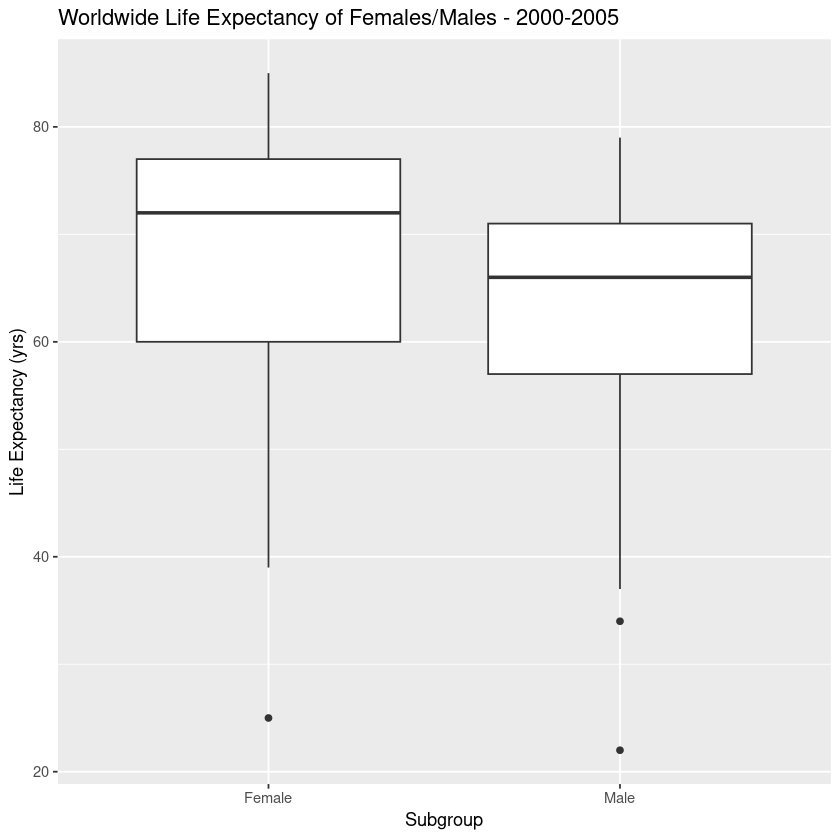

In [134]:
#Q2
    #for some countries (& Subgroups), there is no data for this time period
    #there are 390 rows where 'Year' = "2000-2005", 195 for Females/Males each
    #there is only 1 value in the 'Unit' column: "Years"

#Firstly, inspect life expectancy of females in 2000-2005 overall (worldwide). Can make a boxplot
q2_plot_I <- ggplot(data, aes(x=Subgroup, y=Value)) + geom_boxplot() + 
    labs(title="Worldwide Life Expectancy of Females/Males - 2000-2005", x="Subgroup", y="Life Expectancy (yrs)") +
    theme(plot.title=element_text(size=11), axis.title.x=element_text(size=10), axis.title.y=element_text(size=10))
q2_plot_I

From this boxplot above, the life expectancy of females seems to exceed that of males regardless of country from 2000-2005. Every quantifiable statistic illustrated in this plot (minimum, 1st quantile, median, 3rd quantile, maximum) support this statement.

In [135]:
#Q2 cont.

#Next, investigate across countries
q2_data_I <- data %>%
    #filter for years of interest
    filter(Year == "2000-2005") %>%
    group_by(Country_Area, Subgroup) %>%
    ungroup() %>%
    #select columns of interest
    select(Country_Area, Subgroup, Value) %>%

    #For each country, want to indicate which Subgroup has the higher Value (age), & by how much
    #first, change shape of data
    pivot_wider(names_from=Subgroup, values_from=Value) %>%
    #indicate when the Female life expectancy is >, <, or = to that of Males; obtain the absolute difference in life expectancy
    mutate(higher_LE = case_when(Female>Male ~ "Female", Male>Female ~ "Male", Female==Male ~ "Equal"), 
           abs_LE_diff = abs(Female-Male)) %>%
    #change shape of data into original structure
    pivot_longer(cols=Female:Male, names_to=c("Subgroup")) %>%
    #rename life expectancy column to original name
    rename(Value=value) %>%
    #reorganize the columns
    select(Country_Area, Subgroup, Value, higher_LE, abs_LE_diff)

q2_data_I


Country_Area,Subgroup,Value,higher_LE,abs_LE_diff
<chr>,<chr>,<int>,<chr>,<int>
Afghanistan,Female,42,Equal,0
Afghanistan,Male,42,Equal,0
Albania,Female,79,Female,6
Albania,Male,73,Female,6
Algeria,Female,72,Female,2
Algeria,Male,70,Female,2
Angola,Female,43,Female,4
Angola,Male,39,Female,4
Argentina,Female,78,Female,7


higher_LE,n,min_LE_diff,avg_LE_diff,max_LE_diff
<chr>,<dbl>,<int>,<dbl>,<int>
Equal,4,0,0.000000,0
Female,190,1,4.905263,14
Male,1,1,1.000000,1


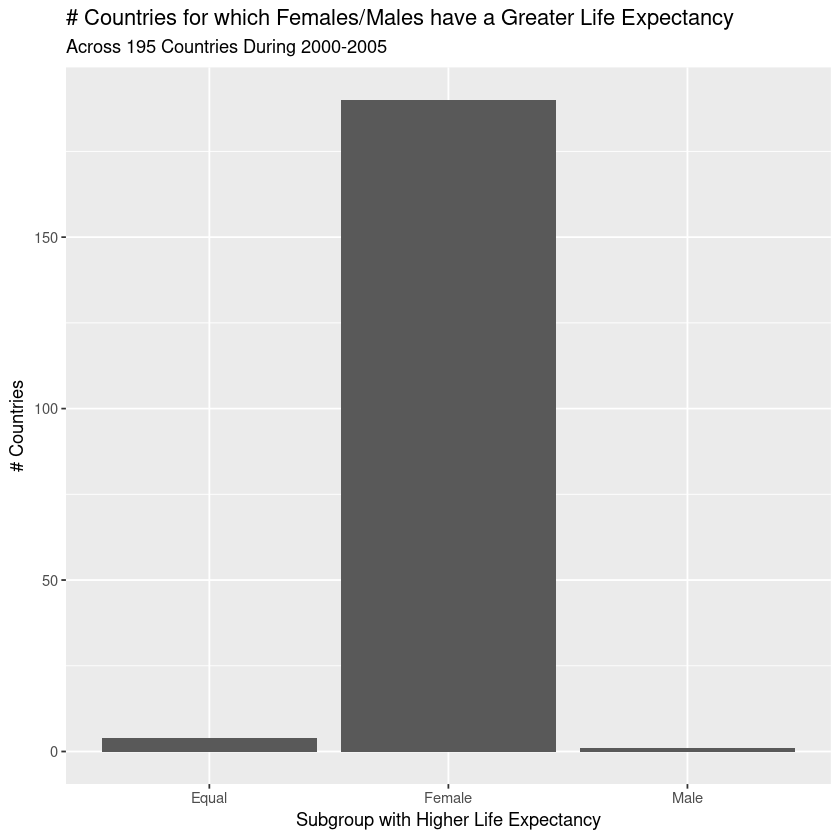

In [136]:
#Q2 cont.

#perform some analysis using these 2 new columns
    #keep in mind that some results might be duplicated because q2_data_I has 2 rows for each country
q2_data_II <- q2_data_I %>%
    group_by(higher_LE) %>%
    #get # countries in which the life expectancy of 1 'Subgroup' exceeds that of the other; get minimum, mean, maximum
        #difference in life expectancy between 'Subgroup's
    summarize(n = n()/2, min_LE_diff = min(abs_LE_diff), avg_LE_diff = mean(abs_LE_diff), max_LE_diff = max(abs_LE_diff))
q2_data_II

#Make a bar plot of this data, illustrating how many countries for which Females/Male have a higher life expectancy
ggplot(q2_data_II, aes(x=higher_LE, y=n)) + geom_col() +
    labs(title="# Countries for which Females/Males have a Greater Life Expectancy", x="Subgroup with Higher Life Expectancy", y="# Countries", subtitle="Across 195 Countries During 2000-2005")

#assign the specified variable
subgroup <- "Female"

The plot above displays the number of countries during 2000-2005 for which a 'Subgroup' (females/males) had a higher life expectancy. This plot contains data for 195 unique countries. Females have a greater life expectancy than males for ~ 97.4% of these countries. Across these 190 countries, females live longer than males by about five years on average.

Given this information, it was determined that females have a longer life expectancy than males across most countries.

# Q3
Which countries exhibit the largest disparities in life expectancy between genders, in the `2000-2005` subgroup? Save the top `3` countries with the largest male-female disparities as a variable named `disparities`.

In [137]:
#Q3
    #this question relates to Q2

q3_data <- q2_data_I %>%
    #sort by largest life expectancy difference
    arrange(desc(abs_LE_diff)) %>%
    #retrieve observations with 3 largest difference in life expectancy -- this retrieves 5 countries because some are tied
    slice_max(abs_LE_diff, n=3)
q3_data
#unique(q3_data$Country_Area)

#assign the specified variable
disparities <- c("Russian Federation", "Belarus", "Estonia")

Country_Area,Subgroup,Value,higher_LE,abs_LE_diff
<chr>,<chr>,<int>,<chr>,<int>
Russian Federation,Female,72,Female,14
Russian Federation,Male,58,Female,14
Belarus,Female,75,Female,12
Belarus,Male,63,Female,12
Estonia,Female,77,Female,12
Estonia,Male,65,Female,12
Kazakhstan,Female,71,Female,12
Kazakhstan,Male,59,Female,12
Lithuania,Female,78,Female,12


The Russian Federation is the country with the largest difference in life expectancy in gender -- females live 14 years longer than males on average. There are four countries with a disparity of 12 years: Belarus, Estonia, Kazakhstan, & Lithuania. For all of these four countries, females live longer than males on average.

In [ ]:
#make a plot
q3_plot_I <- ggplot(data=q3_data, aes(x=Country_Area, y=Value, fill=Subgroup)) + 
    geom_col(position='dodge') + labs(title="Countries w/Greatest Disparity in Life Expectancy per Gender", x="Country/Area", 
                                    y="Life Expectancy (yrs)") +
    theme(plot.title=element_text(size=11), axis.title.x=element_text(size=10),
        axis.title.y=element_text(size=10), legend.title=element_text(size=10),
        axis.text.x=element_text(angle=15, size=8), axis.text.y=element_text(size=8)) +
    scale_y_continuous(breaks=seq(0,80,by=10))
q3_plot_I